In [14]:
import cobra
from modelseedpy import MSBuilder, MSATPCorrection, MSMedia, MSGapfill
import json
from tqdm import tqdm
import cobrakbase

In [2]:
config = cobra.Configuration()
config

Attribute,Description,Value
solver,Mathematical optimization solver,cplex
tolerance,"General solver tolerance (feasibility, integrality, etc.)",1e-07
lower_bound,Default reaction lower bound,-1000.0
upper_bound,Default reaction upper bound,1000.0
processes,Number of parallel processes,335
cache_directory,Path for the model cache,/home/fliu/.cache/cobrapy
max_cache_size,Maximum cache size in bytes,104857600
cache_expiration,Model cache expiration time in seconds (if any),None


In [3]:
mepe = {
    'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs',
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs',
 'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs',
 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs',
 'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}

In [4]:
def _add_atpm(model):
    from cobra.core import Reaction
    if 'ATPM_c0' not in model.reactions:
        atpm = Reaction(f'ATPM_c0', f'ATPM', 'ATPM', 0, 1000)
        atpm.add_metabolites({
            model.metabolites.cpd00001_c0: -1,
            model.metabolites.cpd00002_c0: -1,
            model.metabolites.cpd00008_c0: 1,
            model.metabolites.cpd00009_c0: 1,
            model.metabolites.cpd00067_c0: 1,
        })
        model.add_reactions([atpm])

In [5]:
models_base = {}
for i in tqdm(mepe):
    models_base[i] = cobra.io.load_json_model(f'./models/{i}__.RAST.json')

100%|██████████| 27/27 [00:13<00:00,  1.95it/s]


In [7]:
for model_name in models_base:
    print(model_name)
    model_base = models_base[model_name]
    _add_atpm(model_base)
    disable = ['rxn23850_c0', 'rxn09193_c0', 'rxn05315_c0', 'rxn05206_c0']
    for rxn_id in disable:
        if rxn_id in model_base.reactions:
            rxn = model_base.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0
            rxn.upper_bound = 0
    disable_lb = [
        'rxn09188_c0', 'rxn00929_c0', 
              'rxn00145_c0', 'rxn00499_c0', 'rxn00146_c0',
              'rxn08934_c0', 'rxn08941_c0', 'rxn08935_c0', 'rxn08942_c0', # not sure about these
              'rxn11942_c0', 'rxn11941_c0',
              'rxn43329_c0', 'rxn11940_c0',
              'rxn40559_c0', 'rxn04159_c0', 'rxn04705_c0',
        'rxn14415_c0',
        'sul00003_c0', 'rxn48579_c0',
        'rxn39860_c0'
             ]
    for rxn_id in disable_lb:
        if rxn_id in model_base.reactions:
            rxn = model_base.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0
    rxn_balance_check = ['rxn15395_c0', 'rxn28338_c0']
    for rxn_id in rxn_balance_check:
        if rxn_id in model_base.reactions:
            rxn = model_base.reactions.get_by_id(rxn_id)
            check = {'charge': -1, 'H': -1}
            if rxn.check_mass_balance() == check:
                print(rxn)
                rxn.add_metabolites({
                    model_base.metabolites.cpd00067_c0: +1
                })
                print(rxn.check_mass_balance())
    model_base.medium = {
    'EX_cpd00001_e0': 1000,
    'EX_cpd00067_e0': 1000,
    #'EX_cpd00036_e0': 1,
    'EX_cpd00007_e0': 100,
}
    model_base.objective = 'ATPM_c0'
    sol = cobra.flux_analysis.pfba(model_base)
    if sol.fluxes['ATPM_c0'] > 0.0:
        break
print('no moar loops!')

Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs
Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs
Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs
Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs
Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs
Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs
Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs
Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs
Salt_Pond_MetaG_R2_B_D2_MG_DA

In [42]:
for r in model_base.reactions:
    v = sol.fluxes[r.id]
    if v != 0:
        print(r.id, r.build_reaction_string(True), v, r.check_mass_balance())

In [4]:
model_base = models_base['Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs']

In [8]:
model_base

Name,Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs__.RAST
Memory address,12a0915a0
Number of metabolites,1041
Number of reactions,1021
Number of genes,861
Number of groups,0
Objective expression,1.0*bio1 - 1.0*bio1_reverse_b18f7
Compartments,"Cytosol, Extracellular"


In [10]:
_add_atpm(model_base)

In [21]:
model_base.reactions.rxn09188_c0.lower_bound = 0
model_base.reactions.rxn00929_c0.lower_bound = 0

In [30]:
model_base.reactions.rxn00145_c0.lower_bound = 0
model_base.reactions.rxn00499_c0.lower_bound = 0

In [36]:

model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0

In [41]:
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0
model_base.reactions..lower_bound = 0


In [43]:

model_base.summary(sol)

Metabolite,Reaction,Flux,C-Number,C-Flux
Metabolite,Reaction,Flux,C-Number,C-Flux


In [8]:
template_core = cobrakbase.io.load_kbase_zip_object('./CoreBacV5.1.json.zip')

In [9]:
import os


In [17]:
for model_name in models_base:
    print(model_name)
    model_base = models_base[model_name]
    if not os.path.exists(f'./atp/{model_base.id}.json'):
        model_gapfill = model_base.copy()
        atp_correction = MSATPCorrection(model_gapfill, template_core, medias,
                    compartment='c0', 
                    atp_hydrolysis_id='ATPM_c0',
                    load_default_medias=False)
        tests = atp_correction.run_atp_correction()
        atp_data = conv_atp_results(atp_correction, tests)
        with open(f'./atp/{model_base.id}.json', 'w') as fh:
            fh.write(json.dumps(atp_data))
    else:
        print(f'skip {model_name}!')

Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs
skip Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs!
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs


INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00187 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:Expansion time:empty:0.024326708167791367
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1088
INFO:modelseedpy.core.msmodelutl:Expansion time:Ac.O2:0.012155618984252214
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1088
INFO:modelseedpy.core.msmodelutl:Expansion time:Etho.O2:0.009145119227468967
INFO:modelseedpy.core.msmodel

Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs


INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00027 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00187 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:mod

Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs


...

INFO:modelseedpy.core.msmodelutl:cpd00418 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00418 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00418 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:mod

Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs


INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00116 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00187 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:Expansion time:empty:0.019313769415020943
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1099
INFO:modelseedpy.core.msmodelutl:Expansion time:Glc.O2:0.013423859141767025
INFO:modelseedpy.core.msmodelutl:Filtered count:0 out of 1099
INFO:modelseedpy.core.msmodelutl:Expansion 

Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs


INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00209 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08021 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd00811 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11640 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd11632 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd08701 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:modelseedpy.core.msmodelutl:cpd01024 not found in model!
INFO:mod

In [16]:
def conv_atp_results(atp_correction, tests):
    results = {'tests': {}, 'gapfill': {}}
    for x in tests:
        results['tests'][x['media'].id] = {
            'is_max_threshold': x['is_max_threshold'], 
            'threshold': x['threshold'], 
            'objective': x['objective'], 
        }
    for x in atp_correction.media_gapfill_stats:
        gp_stats = atp_correction.media_gapfill_stats[x]
        #print(x.id, gp_stats)
        if gp_stats:
            results['gapfill'][x.id] = {
                'reversed': gp_stats.get('reversed'),
                'new': gp_stats.get('new'),
                'target': gp_stats.get('target'),
                'minobjective': gp_stats.get('minobjective'),
                'binary_check': gp_stats.get('binary_check'),
            }
    return results

'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs__.RAST'

In [9]:
media_path = '/Users/fliu/workspace/python/env/modelseed/lib/python3.10/site-packages/modelseedpy/data/atp_medias.tsv'
media_path = '/opt/env/modelseed_cplex/lib/python3.10/site-packages/modelseedpy/data/atp_medias.tsv'

In [10]:
min_gap = {
    "Glc.O2": 5,
    "Etho.O2": 0.01,
    "Ac.O2": 1,
    "Pyr.O2": 3,
    "Glyc.O2": 2,
    "Fum.O2": 3,
    "Succ.O2": 2,
    "Akg.O2": 2,
    "LLac.O2": 2,
    "Dlac.O2": 2,
    "For.O2": 1.875,
    "For.NO3": 1.5,
    "Pyr.NO": 2.5,
    "Pyr.NO2": 2.5,
    "Pyr.NO3": 2.5,
    "Pyr.SO4": 2.5,
}
def load_default_medias(default_media_path='/opt/py'):
    import pandas as pd
    filename = default_media_path
    medias = pd.read_csv(filename, sep="\t", index_col=0).to_dict()
    res = []
    for media_id in medias:
        #print(media_id)
        media_d = {}
        for exchange, v in medias[media_id].items():
            if v > 0:
                k = exchange.split("_")[1]
                media_d[k] = v
        media_d["cpd00001"] = 1000
        media_d["cpd00067"] = 1000
        media = MSMedia.from_dict(media_d)
        media.id = media_id
        media.name = media_id
        min_obj = 0.01
        res.append([media, min_gap.get(media.id, min_obj)])
    return res
medias = load_default_medias(media_path)

In [11]:
atp_data = {}
for i in tqdm(mepe):
    with open(f'./atp/{i}__.RAST.json', 'r') as fh:
        atp_data[i] = json.load(fh)

100%|██████████| 27/27 [00:00<00:00, 2659.67it/s]


In [12]:
genome_core_gf = {}
for genome_id in atp_data:
    genome_core_gf[genome_id] = {}
    _data = atp_data[genome_id]
    for cond_id in _data['gapfill']:
        _gapfill_data = _data['gapfill'][cond_id]
        if _gapfill_data['target']:
            _gap_fill_add = list(filter(lambda x: x[:3] != 'EX_', _gapfill_data['new']))
            genome_core_gf[genome_id][cond_id] = len(_gap_fill_add)

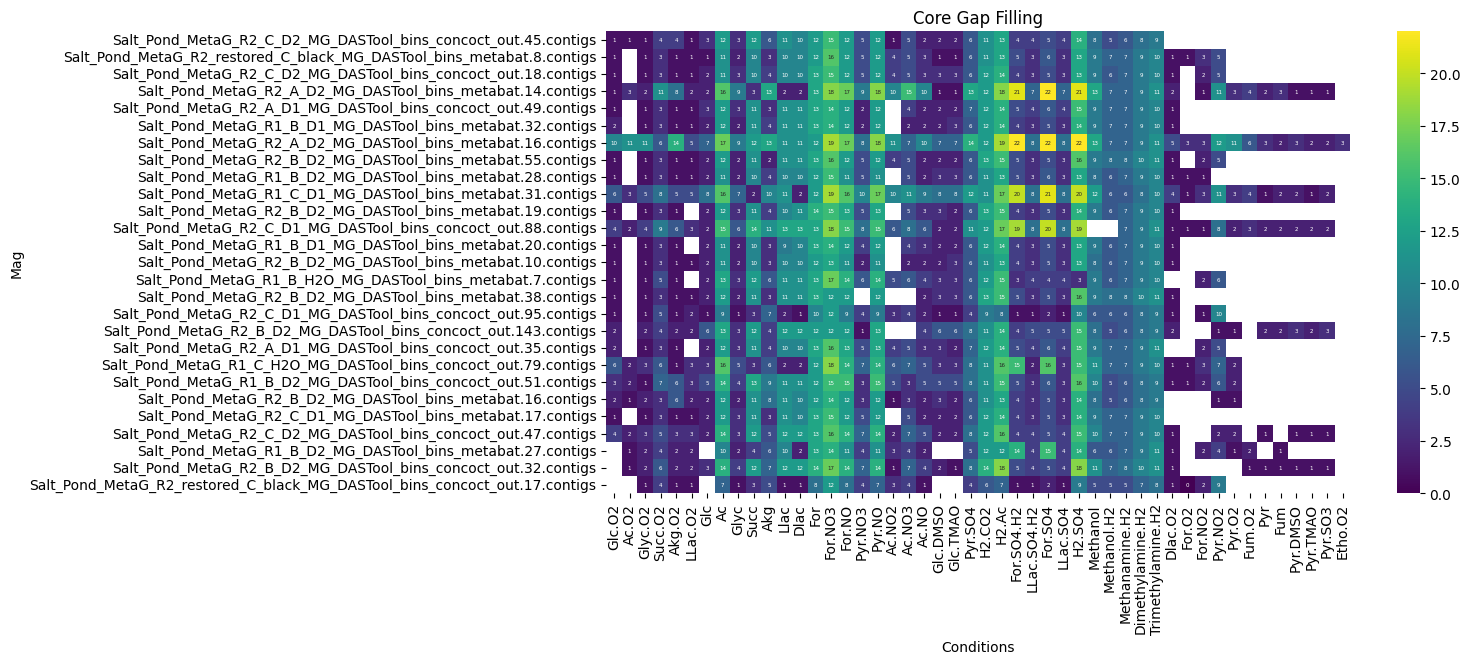

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Corrected dictionary
d = genome_core_gf

# Convert to DataFrame
df = pd.DataFrame.from_dict(d, orient='index')
plt.figure(figsize=(12, 6))
# Plot heatmap
sns.heatmap(df, annot=True, cmap='viridis', annot_kws={"size": 4})
plt.title("Core Gap Filling")
plt.ylabel("Mag")
plt.xlabel("Conditions")
plt.show()

In [52]:
model_base = models_base['Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs']

In [68]:
atp_data['Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs']['gapfill']['LLac.O2']

{'reversed': {},
 'new': {'EX_cpd00159_e0': '>', 'rxn05602_c0': '>'},
 'target': 'ATPM_c0',
 'minobjective': 2,
 'binary_check': False}

In [ ]:
llac_o2

In [65]:
pyr_tmao = list(filter(lambda x: x[0].id == 'Pyr.TMAO', medias))[0][0]
glyc_o2 = list(filter(lambda x: x[0].id == 'Glyc.O2', medias))[0][0]
llac_o2 = list(filter(lambda x: x[0].id == 'LLac.O2', medias))[0][0]

In [66]:
llac_o2.get_media_constraints()

{'cpd00159_e0': (-1, 1000),
 'cpd00007_e0': (-1000, 1000),
 'cpd00001_e0': (-1000, 1000),
 'cpd00067_e0': (-1000, 1000)}

In [72]:
model_base.add_reactions([template_core.reactions.rxn05602_c.to_reaction(model_base)])

In [75]:
MSBuilder.add_exchanges_to_model(model_base)

[<Reaction EX_cpd00159_e0 at 0x7e1abc67da20>]

In [76]:
model_base.medium = {
    'EX_cpd00067_e0': 1000, 
    'EX_cpd00001_e0': 1000, 
    'EX_cpd00007_e0': 1,
    'EX_cpd00159_e0': 1000,
}

In [96]:
rxn_scan = ['rxn26456_c0', 'rxn26457_c0', 'rxs43120_c0', 'rxn26447_c0', 'rxn04651_c0']
_plot_data = {}
for model_id in models_base:
    model_base = models_base[model_id]
    _plot_data[model_id] = {x: x in model_base.reactions for x in rxn_scan}

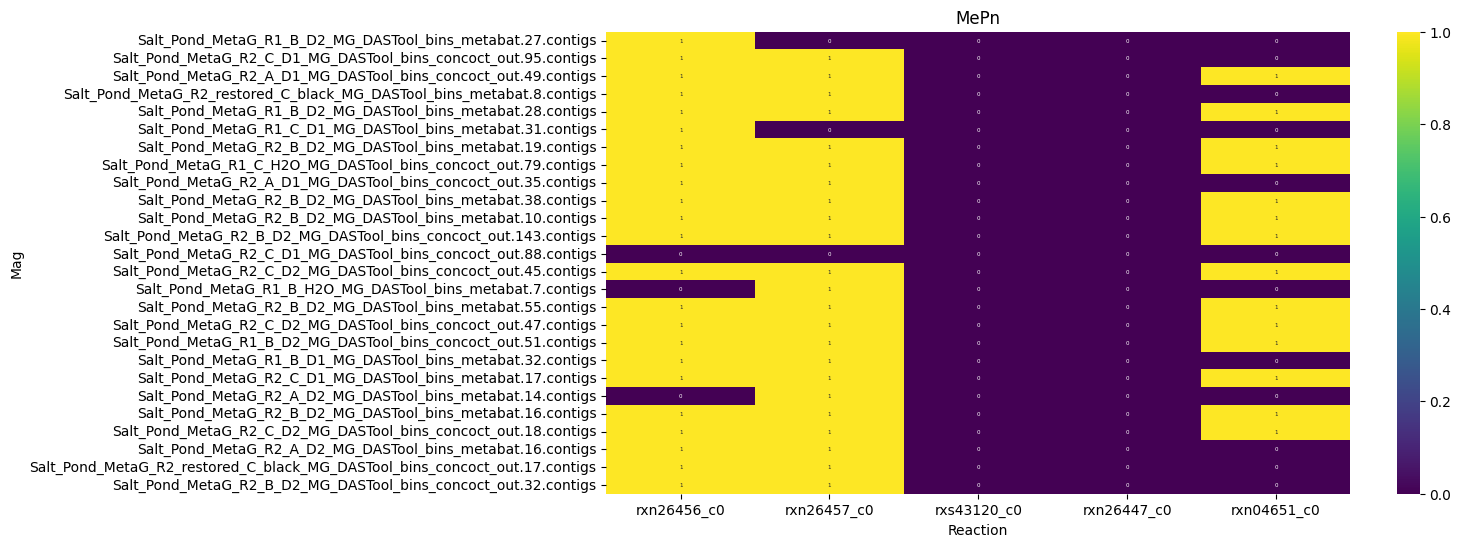

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Corrected dictionary
d = _plot_data

# Convert to DataFrame
df = pd.DataFrame.from_dict(d, orient='index')
plt.figure(figsize=(12, 6))
# Plot heatmap
sns.heatmap(df, annot=True, cmap='viridis', annot_kws={"size": 4})
plt.title("MePn")
plt.ylabel("Mag")
plt.xlabel("Reaction")
plt.show()

In [118]:
cpd_inject = {'cpd26508_c0', 'cpd01024_c0'}
_to_add = []
for cpd_id in cpd_inject:
    if cpd_id not in model_base.metabolites:
        _to_add.append(template_neg.compcompounds.get_by_id(cpd_id[:-1]).to_metabolite())
model_base.add_metabolites(_to_add)
_to_add

[]

In [152]:
rxs00001_c0 = Reaction('rxs00001_c0', 'MePn ABC Transporter', 'MePn Degradation', 0, 1000)
rxs00001_c0.add_metabolites({
    model_base.metabolites.cpd00001_c0: -1,
    model_base.metabolites.cpd00002_c0: -1,
    model_base.metabolites.cpd00008_c0:  1,
    model_base.metabolites.cpd00009_c0:  1,
    model_base.metabolites.cpd00067_c0:  1,

    model_base.metabolites.cpd25960_e0: -1,
    model_base.metabolites.cpd25960_c0:  1,
})
print(rxs00001_c0.check_mass_balance())
rxs00001_c0

{'charge': -1}


Reaction identifier,rxs00001_c0
Name,MePn ABC Transporter
Memory address,0x7e1abb77db10
Stoichiometry,cpd00001_c0 + cpd00002_c0 + cpd25960_e0 --> cpd00008_c0 + cpd00009_c0 + cpd00067_c0 + cpd25960_c0 H2O [c0] + ATP [c0] + MePn [e0] --> ADP [c0] + Phosphate [c0] + H+ [c0] + MePn [c0]
GPR,
Lower bound,0
Upper bound,1000


In [153]:
model_base.metabolites.cpd25960_c0.charge

-1

In [150]:
from cobra.core import Metabolite
cpd_mepn_e0 = Metabolite('cpd25960_e0', 'CH4O3P', 'MePn [e0]', -1, 'e0')
model_base.add_metabolites([cpd_mepn_e0])

In [128]:
from cobra.core import Reaction
rxs43120_c0 = Reaction('rxs43120_c0', 'rxs43120_c0', 'MePn Degradation', 0, 1000)
rxs43120_c0.add_metabolites({
    model_base.metabolites.cpd00017_c0: -1,
    model_base.metabolites.cpd26519_c0: -1,
    model_base.metabolites.cpd01024_c0:  1,
    model_base.metabolites.cpd03091_c0:  1,
    model_base.metabolites.cpd00060_c0:  1,
    model_base.metabolites.cpd26508_c0:  1,

    model_base.metabolites.cpd00003_c0: +1,
    model_base.metabolites.cpd00004_c0: -1,
})
print(rxs43120_c0.check_mass_balance())
rxs43120_c0

{}


Reaction identifier,rxs43120_c0
Name,rxs43120_c0
Memory address,0x7e1abb787010
Stoichiometry,"cpd00004_c0 + cpd00017_c0 + cpd26519_c0 --> cpd00003_c0 + cpd00060_c0 + cpd01024_c0 + cpd03091_c0 + cpd26508_c0 NADH [c0] + S-Adenosyl-L-methionine [c0] + PRPn [c0] --> NAD [c0] + L-Methionine [c0] + Methane [c0] + 5'-Deoxyadenosine [c0] + 5-phospho-alpha-D-ribosyl 1,2-cyclic phosphate [c0]"
GPR,
Lower bound,0
Upper bound,1000


In [137]:
template_reaction = template_neg.reactions.get_by_id('rxn26456_c')

In [138]:
template_reaction

Reaction identifier,rxn26456_c0
Name,RXN0-6732.c [c0]
Memory address,0x7e1abbc15d20
Stoichiometry,cpd00002_c0 + cpd25960_c0 --> cpd00128_c0 + cpd26518_c0 ATP [c0] + MePn [c0] --> Adenine [c0] + RPnTP [c0]
GPR,
Lower bound,0
Upper bound,1000


In [154]:
pathway_rxn_mepn = [
    rxs00001_c0,
    template_neg.reactions.get_by_id('rxn26456_c').to_reaction(model_base),
    template_neg.reactions.get_by_id('rxn26457_c').to_reaction(model_base),
    rxs43120_c0,
    template_neg.reactions.get_by_id('rxn26447_c').to_reaction(model_base),
    template_neg.reactions.get_by_id('rxn04651_c').to_reaction(model_base),
]
pathway_rxn_mepn[4].add_metabolites({
    model_base.metabolites.cpd00067_c0: -2
})
pathway_rxn_mepn

[<Reaction rxs00001_c0 at 0x7e1abb77db10>,
 <Reaction rxn26456_c0 at 0x7e1abb77c310>,
 <Reaction rxn26457_c0 at 0x7e1abb77d7b0>,
 <Reaction rxs43120_c0 at 0x7e1abb787010>,
 <Reaction rxn26447_c0 at 0x7e1abb77d9c0>,
 <Reaction rxn04651_c0 at 0x7e1ab7a986a0>]

In [174]:
for rxn in pathway_rxn_mepn:
    print(rxn.id)
    print(rxn.build_reaction_string(True))
    print(rxn.check_mass_balance())
    print()

rxs00001_c0
H2O [c0] + ATP [c0] + MePn [e0] --> ADP [c0] + Phosphate [c0] + H+ [c0] + MePn [c0]
{'charge': -1}

rxn26456_c0
ATP [c0] + MePn [c0] --> Adenine [c0] + RPnTP [c0]
{}

rxn26457_c0
H2O [c0] + RPnTP [c0] --> PPi [c0] + 2 H+ [c0] + PRPn [c0]
{}

rxs43120_c0
NADH [c0] + S-Adenosyl-L-methionine [c0] + PRPn [c0] --> NAD [c0] + L-Methionine [c0] + Methane [c0] + 5'-Deoxyadenosine [c0] + 5-phospho-alpha-D-ribosyl 1,2-cyclic phosphate [c0]
{}

rxn26447_c0
H2O [c0] + 5-phospho-alpha-D-ribosyl 1,2-cyclic phosphate [c0] <=> H+ [c0] + Ribose 1,5-bisphosphate [c0]
{'charge': 2, 'H': 2}

rxn04651_c0
ATP [c0] + Ribose 1,5-bisphosphate [c0] --> ADP [c0] + H+ [c0] + PRPP [c0]
{}



In [182]:
pathway_rxn_mepn_total = pathway_rxn_mepn[0] + pathway_rxn_mepn[1] + pathway_rxn_mepn[2] + pathway_rxn_mepn[3] + pathway_rxn_mepn[4] + pathway_rxn_mepn[5]

In [183]:
pathway_rxn_mepn_total.check_mass_balance()

{'charge': -1}

In [81]:
model_base.reactions.rxn26457_c0

Reaction identifier,rxn26457_c0
Name,RXN0-6733.c [c0]
Memory address,0x7e4864307d90
Stoichiometry,cpd00001_c0 + cpd26518_c0 --> cpd00012_c0 + 2 cpd00067_c0 + cpd26519_c0 H2O [c0] + RPnTP [c0] --> PPi [c0] + 2 H+ [c0] + PRPn [c0]
GPR,Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs__.RAST.CDS.2006 or...
Lower bound,0.0
Upper bound,1000.0


In [82]:
template_neg = cobrakbase.io.load_kbase_zip_object('./GramNegModelTemplateV6_test.json.zip')

In [ ]:
template_neg.reactions.rxn43120_c

In [86]:
template_neg.reactions.rxn26447_c

Reaction identifier,rxn26447_c
Name,RXN0-6710.c
Memory address,0x7e1ab8ea7130
Stoichiometry,"cpd00001_c + cpd26508_c <=> cpd00067_c + cpd00847_c H2O [c] + 5-phospho-alpha-D-ribosyl 1,2-cyclic phosphate [c] <=> H+ [c] + Ribose 1,5-bisphosphate [c]"
GPR,tcpx01009
Lower bound,-1000
Upper bound,1000


In [87]:
template_neg.reactions.rxn04651_c

Reaction identifier,rxn04651_c
Name,"ATP:ribose-1,5-bisphosphate phosphotransferase"
Memory address,0x7e1ab952b130
Stoichiometry,"cpd00002_c + cpd00847_c --> cpd00008_c + cpd00067_c + cpd00103_c ATP [c] + Ribose 1,5-bisphosphate [c] --> ADP [c] + H+ [c] + PRPP [c]"
GPR,tcpx00927
Lower bound,0
Upper bound,1000


In [129]:
pathway_rast_mepn = {
'phnCDE': [
        'Phosphonate ABC transporter substrate-binding protein PhnD (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter ATP-binding protein PhnC (TC 3.A.1.9.1)',
        'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1); Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
    ],
    'phnI': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate synthase subunit PhnI (EC 2.7.8.37)'
    ],
    'phnM': [
        'Alpha-D-ribose 1-methylphosphonate 5-triphosphate diphosphatase (EC 3.6.1.63)'
    ],
    'phnJ': [
        'Alpha-D-ribose 1-methylphosphonate 5-phosphate C-P lyase (EC 4.7.1.1)'
    ],
    'phnN': [
        'Ribose 1,5-bisphosphate phosphokinase PhnN (EC 2.7.4.23)',
    ],
}

In [171]:
import tarfile
from tqdm import tqdm
rast_annotation = {}
with tarfile.open('/storage/fliu/data/cliff/genomes/salterns.rast.tar.gz', "r:gz") as fh_tar:
    for member in tqdm(fh_tar.getmembers()):
        if member.isfile():
            file = fh_tar.extractfile(member)
            if file:
                content = file.read()
                rast_data = json.loads(bytearray(content))
                _d = {}
                for o in rast_data[0]['features']:
                    _d[o['id']] = o.get('function', 'hypothetical protein')
                rast_annotation.update(_d)
len(rast_annotation)

ani_library_derep_genomes.txt  fna  salterns.rast.tar.gz


100%|██████████| 68/68 [00:19<00:00,  3.43it/s]


1358000

In [195]:
for i, model in models_base.items():
    for rxn in pathway_rxn_mepn:
        if rxn.id not in model.reactions:
            #print(i, rxn)
            pass
        else:
            print(i, rxn.id)

Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs rxn26456_c0
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs rxn26456_c0
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs rxn26457_c0
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs rxn26456_c0
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs rxn26457_c0
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs rxn04651_c0
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs rxn26456_c0
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs rxn26457_c0
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs rxn26456_c0
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs rxn26457_c0
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs rxn04651_c0
Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs rxn26456_c0
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs rxn26456_c0
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_

In [ ]:
rxs00001_c0 = Reaction('rxs00001_c0', 'MePn ABC Transporter', 'MePn Degradation', 0, 1000)
rxs00001_c0.add_metabolites({
    model_base.metabolites.cpd00001_c0: -1,
    model_base.metabolites.cpd00002_c0: -1,
    model_base.metabolites.cpd00008_c0:  1,
    model_base.metabolites.cpd00009_c0:  1,
    model_base.metabolites.cpd00067_c0:  1,

    model_base.metabolites.cpd25960_e0: -1,
    model_base.metabolites.cpd25960_c0:  1,
})
print(rxs00001_c0.check_mass_balance())
rxs00001_c0

In [200]:
atp_data['Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs']['tests']

{'empty': {'is_max_threshold': True,
  'threshold': 1e-05,
  'objective': 'ATPM_c0'},
 'Ac.O2': {'is_max_threshold': True, 'threshold': 9.0, 'objective': 'ATPM_c0'},
 'Etho.O2': {'is_max_threshold': True,
  'threshold': 14.7,
  'objective': 'ATPM_c0'},
 'Pyr.O2': {'is_max_threshold': True,
  'threshold': 12.449999999999894,
  'objective': 'ATPM_c0'},
 'Fum.O2': {'is_max_threshold': True,
  'threshold': 16.200000000000006,
  'objective': 'ATPM_c0'},
 'Dlac.O2': {'is_max_threshold': True,
  'threshold': 14.699999999999964,
  'objective': 'ATPM_c0'},
 'For.O2': {'is_max_threshold': True,
  'threshold': 2.2499999999998925,
  'objective': 'ATPM_c0'},
 'Pyr': {'is_max_threshold': True, 'threshold': 0.6, 'objective': 'ATPM_c0'},
 'Fum': {'is_max_threshold': True, 'threshold': 1.5, 'objective': 'ATPM_c0'},
 'For.NO2': {'is_max_threshold': True,
  'threshold': 1.6500000000000852,
  'objective': 'ATPM_c0'},
 'Pyr.NO2': {'is_max_threshold': True,
  'threshold': 9.450000000000085,
  'objective': '